#### IMDB(Internet Movie Data Base)
- Train Data(25000개중 긍정 12500, 부정 12500), Test Data(25000개중 긍정 12500, 부정 12500개)
- NLP : Natural Language Processong(자연어 처리)
- 말뭉치 : 하나의 데이터셋
- 토큰 : 하나의 단어
- 어휘사전 : 번호로 구분된 유일한 단어들의 집단

#### Keras로 IMDB Data 불러오기
: 어휘사전이 이미 숫자로 변환되어 있음

In [2]:
from tensorflow.keras.datasets import imdb

(train_input,train_target),(test_input,test_target) = imdb.load_data(num_words=500)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
# train과 test의 크기 
print(len(train_input),len(test_input))

25000 25000


In [4]:
# train의 첫번째 문장의 Token 갯수
len(train_input[0])

218

In [9]:
# train의 두번째 문장의 Token 갯수
len(train_input[1])

189

In [10]:
# 첫번째 댓글의 출력
len(train_input[0])

218

#### IMDB 데이터 확인
- Sample의 시작은 토큰을 1로 사용
- 2는 선정한 단어수에 포함되지 않은 단어
- 문장의 길이가 달라서 List로 되어 있다.

In [12]:
# train target
print(train_target[:10])

[1 0 0 1 0 0 1 0 1 0]


In [11]:
# 첫번째 댓글의 토큰 출력
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


---
### 훈련 세트


In [15]:
from sklearn.model_selection import train_test_split

train_input,val_input,train_target,val_target = train_test_split(
                                                        train_input,
                                                        train_target,
                                                        test_size=0.2,
                                                        random_state=42

)

#### 각 리뷰마다 문장길이를 시각화

In [13]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

print(np.mean(lengths), np.median(lengths))

238.71364 178.0


> 중앙값보다 평균이 크므로 예상치 않게 길게 달린 댓글이 있다고 예측

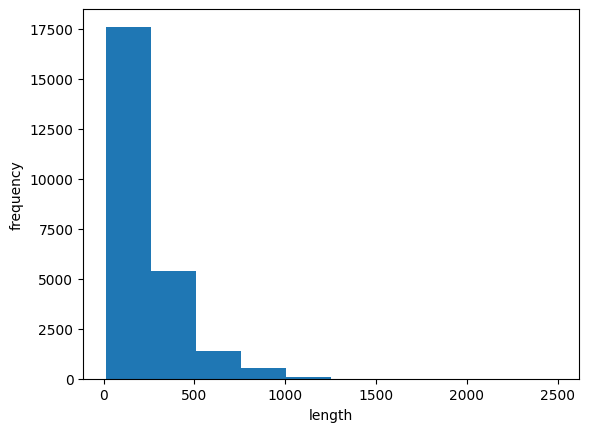

In [14]:
import matplotlib.pyplot as plt

plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

---
#### Sequence Padding

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100) # 짜르는 거 _모자르면 붙이고 자르는 거 
val_seq = pad_sequences(val_input, maxlen=100)

In [19]:
# 크기 확인
train_seq.shape

(20000, 100)

In [18]:
# 크기 확인
print(train_seq.shape, val_seq.shape)

(20000, 100) (5000, 100)


In [20]:
# 첫번째 샘플의 패딩 결과 확인
print(train_seq[0])

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [21]:
# 원본에서 확인
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 470, 158]


In [22]:
train_seq

array([[ 10,   4,  20, ...,  10, 470, 158],
       [206,   2,  26, ...,   6,   2,   2],
       [  2,   7,   2, ...,   2,   2,  12],
       ...,
       [  2,  37, 299, ...,   7,  14,   2],
       [  0,   0,   0, ...,  25, 170,   2],
       [  0,   0,   0, ...,  25, 194,   2]],
      shape=(20000, 100), dtype=int32)

In [24]:
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


---
### 순환 신경망 모델 만들기

In [36]:
from tensorflow import keras

model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),   # 리뷰 1개의 길이: 토큰 100개
        keras.layers.Embedding(500, output_dim=16),   # 500: 자주 등장하는 단어 갯수 정의 / 500개 단어를 각각 16차원 벡터로 변환
        keras.layers.SimpleRNN(8),          # 문장 전체 정보를 8개의 값으로 요약
        keras.layers.Dense(1, activation='sigmoid')  # 긍정/부정 이진 분류
    ]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 테스트 세트
test_seq = pad_sequences(test_input, maxlen=100)
print(train_seq.shape, val_seq.shape, test_seq.shape)

(20000, 100) (5000, 100) (25000, 100)


In [38]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

#### 순환 신경망 훈련하기

In [39]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
# LSTM 모델 컴파일
# - RMSprop : 순환 신경망에서 자주 사용하는 옵티마이저
# - learning_rate=1e-4 : 학습률을 작게 설정해서 안정적으로 학습
# - binary_crossentropy : 긍정/부정 이진 분류 손실 함수
# - accuracy : 정확도 확인
model.compile(
    optimizer=rmsprop,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best-simplernn-model.keras")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)


# 모델 학습
# - train_seq : 패딩된 훈련 데이터
# - train_target : 훈련 데이터의 정답
# - epochs=100 : 최대 100번 반복 학습
# - batch_size=64 : 64개씩 묶어서 학습
# - validation_data : 검증 데이터로 학습 중 성능 확인
# - callbacks : 가장 좋은 모델 저장 + 성능이 안 좋아지면 조기 종료
history = model.fit(
            train_seq,
            train_target,
            epochs=100, # early_stopping 있어서 괜찮다
            batch_size=128,
            validation_data=(val_seq, val_target),
            callbacks=[checkpoint_cb, early_stopping_cb]
)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5072 - loss: 0.6942 - val_accuracy: 0.5558 - val_loss: 0.6856
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6137 - loss: 0.6754 - val_accuracy: 0.6362 - val_loss: 0.6696
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6668 - loss: 0.6614 - val_accuracy: 0.6492 - val_loss: 0.6632
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6977 - loss: 0.6482 - val_accuracy: 0.7042 - val_loss: 0.6457
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7180 - loss: 0.6353 - val_accuracy: 0.7144 - val_loss: 0.6339
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7325 - loss: 0.6226 - val_accuracy: 0.7178 - val_loss: 0.6235
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7409 - loss: 0.6098 - val_accuracy: 0.7172 - val_loss: 0.6164
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7489 - loss: 0.5970 - v

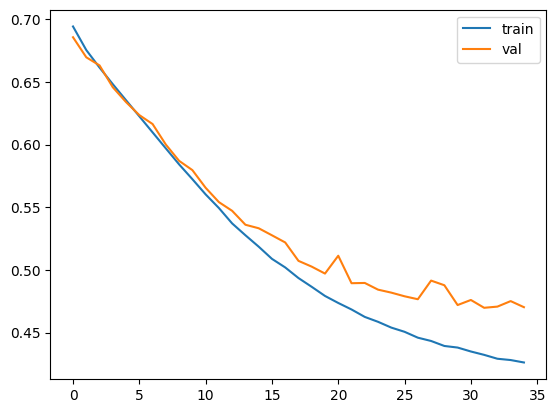

In [41]:
# 시각화 해보기
# plt.plot(history.history['loss'])
# plt.plot(history.history['val_cross'])
# plt.legend(['train','val'])
# plt.show()

# 시각화 해보기
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()


In [ ]:
val